# Task 4: Predicting Insurance Claim Amounts

## Research Purpose

This notebook studies medical insurance charges as a regression problem. The main question is: which customer attributes are most connected with higher insurance charges, and how accurately can a transparent baseline model estimate those charges?

This is the first notebook in the set where linear and multiple regression are directly appropriate, because the target variable `charges` is continuous. I use descriptive statistics, exploratory visuals, statistical testing, VIF, ordinary least squares-style interpretation, Ridge/Lasso regularization, and residual diagnostics. I also keep the interpretation careful because medical-cost modeling has real fairness, compliance, and ethical implications.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette=["#264653", "#E76F51", "#2A9D8F", "#F4A261"],
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
    },
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## Dataset Loading and First Look

In [2]:
local_path = DATA_DIR / "insurance.csv"
if not local_path.exists():
    raise FileNotFoundError(f"Expected local dataset at {local_path}.")

raw_df = pd.read_csv(local_path)

print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]:,}")
raw_df.head()

Rows: 1,338
Columns: 7


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Research note:** The dataset is simple but analytically useful. It has demographic and lifestyle fields, plus the continuous `charges` target. Since the target is a currency-like amount with strong skew, I will evaluate both raw charges and log-transformed charges.

In [3]:
quality_report = pd.DataFrame(
    {
        "dtype": raw_df.dtypes.astype(str),
        "missing_values": raw_df.isna().sum(),
        "missing_rate": raw_df.isna().mean(),
        "unique_values": raw_df.nunique(dropna=True),
    }
).sort_values(["missing_values", "unique_values"], ascending=[False, False])

display(quality_report)
print(f"Duplicate rows: {raw_df.duplicated().sum()}")

,dtype,missing_values,missing_rate,unique_values
charges,float64,0,0.0,1337
bmi,float64,0,0.0,548
age,int64,0,0.0,47
children,int64,0,0.0,6
region,object,0,0.0,4
sex,object,0,0.0,2
smoker,object,0,0.0,2


Duplicate rows: 1


## Cleaning and Feature Setup

In [4]:
df = raw_df.drop_duplicates().copy()

target = "charges"
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

df["log_charges"] = np.log1p(df["charges"])
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["underweight", "normal", "overweight", "obese"],
)
df["age_band"] = pd.cut(
    df["age"],
    bins=[17, 30, 45, 60, 70],
    labels=["18-30", "31-45", "46-60", "61+"],
)

model_numeric = numeric_features
model_categorical = categorical_features

X = df[model_numeric + model_categorical]
y = df[target]
y_log = df["log_charges"]

display(df.head())

,age,sex,bmi,children,smoker,region,charges,log_charges,bmi_category,age_band
0,19,female,27.900,0,yes,southwest,16884.92400,9.734236,overweight,18-30
1,18,male,33.770,1,no,southeast,1725.55230,7.453882,obese,18-30
2,28,male,33.000,3,no,southeast,4449.46200,8.400763,obese,18-30
3,33,male,22.705,0,no,northwest,21984.47061,9.998137,normal,31-45
4,32,male,28.880,0,no,northwest,3866.85520,8.260455,overweight,31-45


## Descriptive Statistical Analytics

In [5]:
overall_stats = df[["age", "bmi", "children", "charges"]].agg(
    ["count", "mean", "median", "std", "min", "max", "skew"]
).T.round(2)

overall_stats["iqr"] = (
    df[["age", "bmi", "children", "charges"]].quantile(0.75)
    - df[["age", "bmi", "children", "charges"]].quantile(0.25)
).round(2)

overall_stats

,count,mean,median,std,min,max,skew,iqr
age,1337.0,39.22,39.00,14.04,18.00,64.00,0.05,24.00
bmi,1337.0,30.66,30.40,6.10,15.96,53.13,0.28,8.41
children,1337.0,1.10,1.00,1.21,0.00,5.00,0.94,2.00
charges,1337.0,13279.12,9386.16,12110.36,1121.87,63770.43,1.52,11911.37


In [6]:
smoker_summary = (
    df.groupby("smoker")["charges"]
    .agg(customers="count", mean_charge="mean", median_charge="median", std_charge="std")
    .round(2)
)

region_summary = (
    df.groupby("region")["charges"]
    .agg(customers="count", mean_charge="mean", median_charge="median")
    .sort_values("mean_charge", ascending=False)
    .round(2)
)

display(smoker_summary)
display(region_summary)

,customers,mean_charge,median_charge,std_charge
smoker,,,,
no,1063,8440.66,7345.73,5992.97
yes,274,32050.23,34456.35,11541.55


,customers,mean_charge,median_charge
region,,,
southeast,364,14735.41,9294.13
northeast,324,13406.38,10057.65
northwest,324,12450.84,8976.98
southwest,325,12346.94,8798.59


**Research note:** Charges are strongly skewed, which is normal in medical-cost data. A small number of high-cost cases can pull the mean upward. That is why the notebook looks at medians, log charges, and residual behavior instead of trusting one summary number.

## Exploratory Visual Analytics

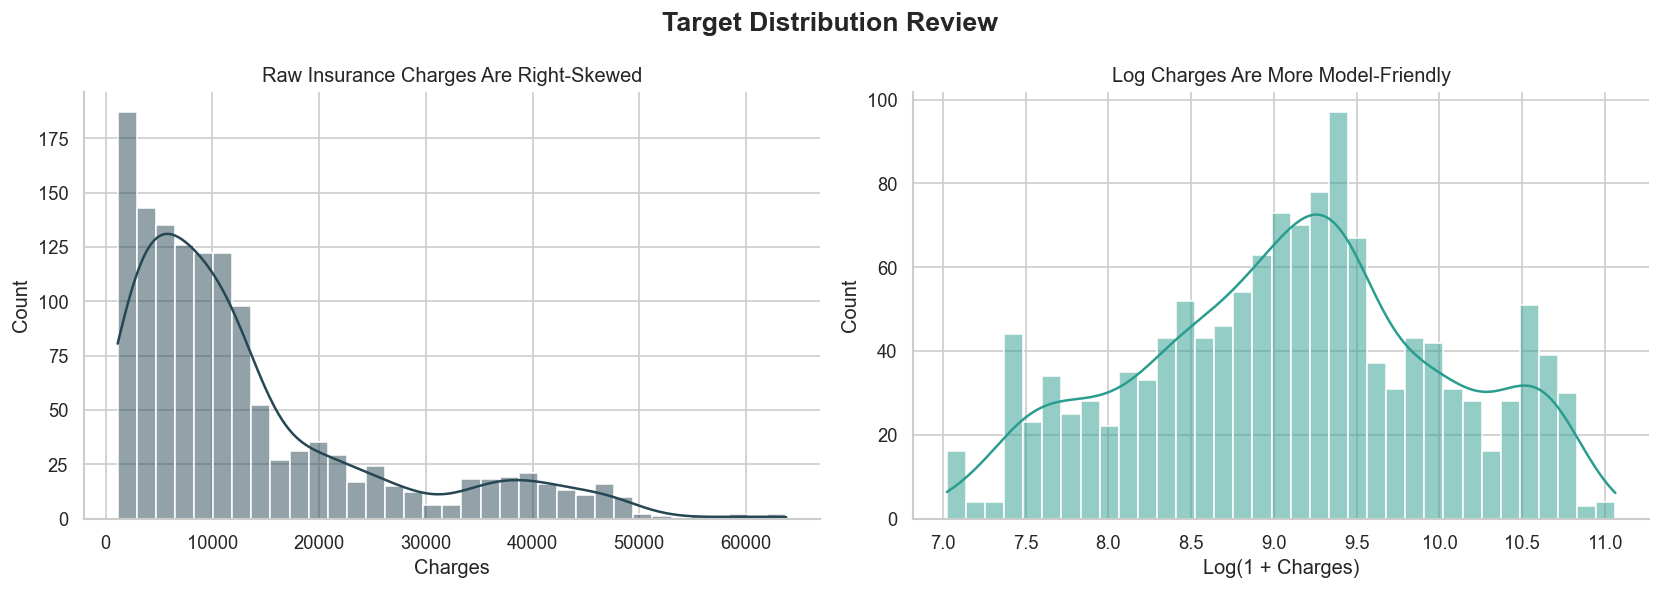

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="charges", kde=True, bins=35, ax=axes[0], color="#264653")
axes[0].set_title("Raw Insurance Charges Are Right-Skewed")
axes[0].set_xlabel("Charges")

sns.histplot(data=df, x="log_charges", kde=True, bins=35, ax=axes[1], color="#2A9D8F")
axes[1].set_title("Log Charges Are More Model-Friendly")
axes[1].set_xlabel("Log(1 + Charges)")

fig.suptitle("Target Distribution Review", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task4_target_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

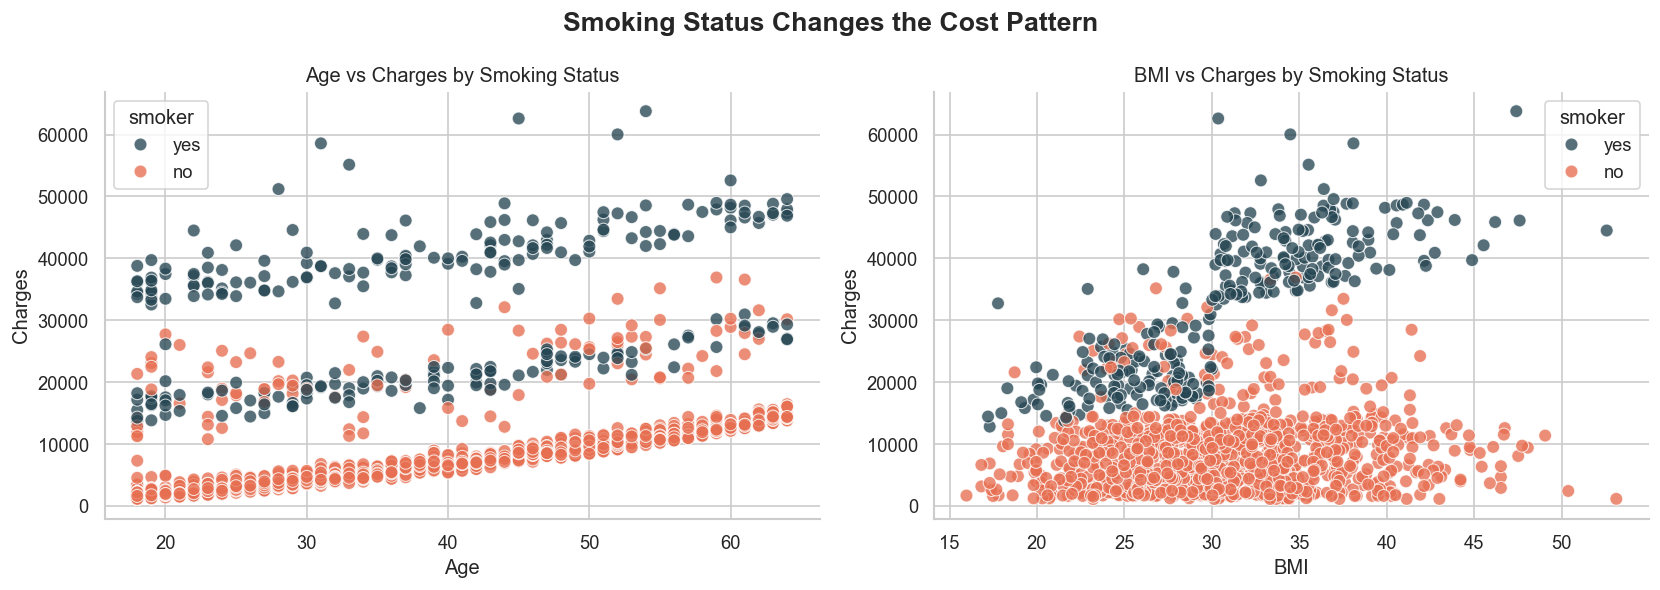

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.78, s=60, ax=axes[0])
axes[0].set_title("Age vs Charges by Smoking Status")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Charges")

sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.78, s=60, ax=axes[1])
axes[1].set_title("BMI vs Charges by Smoking Status")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Charges")

fig.suptitle("Smoking Status Changes the Cost Pattern", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task4_age_bmi_charges_smoker.png", dpi=180, bbox_inches="tight")
plt.show()

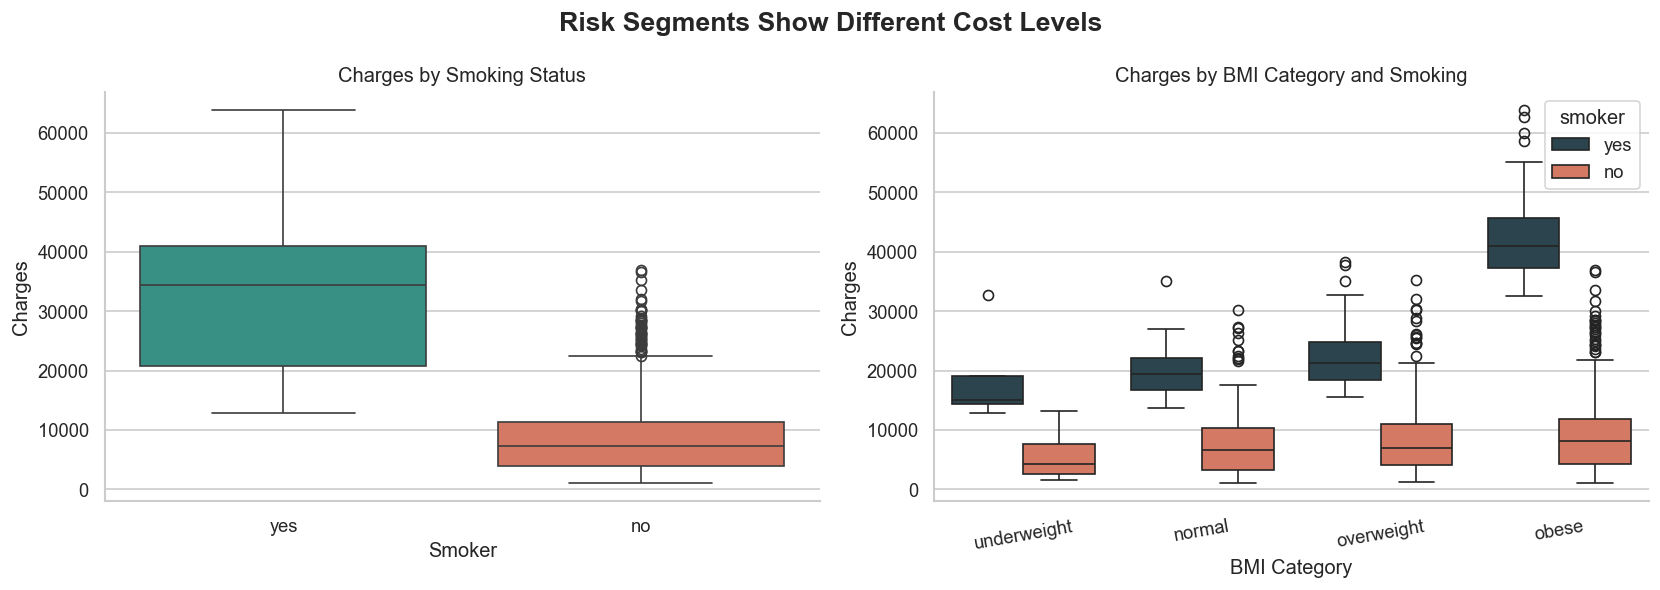

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="smoker", y="charges", ax=axes[0], palette=["#2A9D8F", "#E76F51"])
axes[0].set_title("Charges by Smoking Status")
axes[0].set_xlabel("Smoker")
axes[0].set_ylabel("Charges")

sns.boxplot(data=df, x="bmi_category", y="charges", hue="smoker", ax=axes[1])
axes[1].set_title("Charges by BMI Category and Smoking")
axes[1].set_xlabel("BMI Category")
axes[1].set_ylabel("Charges")
axes[1].tick_params(axis="x", rotation=10)

fig.suptitle("Risk Segments Show Different Cost Levels", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task4_smoker_bmi_boxplots.png", dpi=180, bbox_inches="tight")
plt.show()

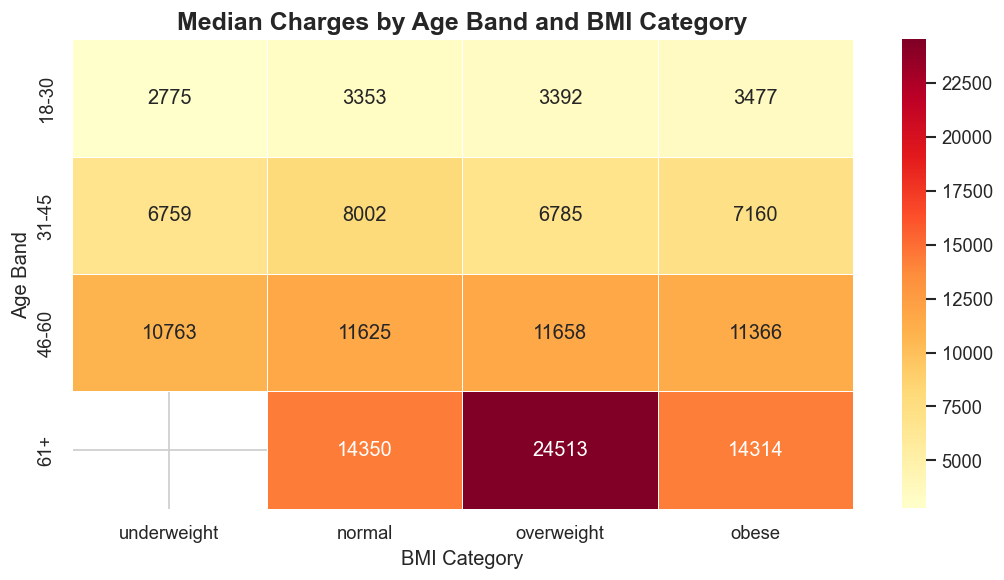

bmi_category,underweight,normal,overweight,obese
age_band,,,,
18-30,2775.19,3353.47,3392.37,3476.64
31-45,6759.26,8001.77,6784.83,7160.21
46-60,10762.96,11624.89,11658.25,11365.95
61+,NaN,14349.85,24513.09,14313.85


In [10]:
heatmap_data = (
    df.groupby(["age_band", "bmi_category"], observed=False)["charges"]
    .median()
    .reset_index()
    .pivot(index="age_band", columns="bmi_category", values="charges")
)

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title("Median Charges by Age Band and BMI Category", fontsize=15, fontweight="bold")
plt.xlabel("BMI Category")
plt.ylabel("Age Band")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task4_age_bmi_median_charge_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

heatmap_data.round(2)

## Statistical Tests and Practical Signal

In [11]:
test_rows = []

for col in ["age", "bmi", "children"]:
    rho, p_value = stats.spearmanr(df[col], df["charges"])
    test_rows.append(
        {
            "feature": col,
            "test": "Spearman correlation",
            "effect": rho,
            "p_value": p_value,
        }
    )

for col in ["sex", "smoker", "region", "bmi_category", "age_band"]:
    groups = [group["charges"].values for _, group in df.groupby(col, observed=False)]
    h_stat, p_value = stats.kruskal(*groups)
    test_rows.append(
        {
            "feature": col,
            "test": "Kruskal-Wallis",
            "effect": h_stat,
            "p_value": p_value,
        }
    )

test_table = pd.DataFrame(test_rows).sort_values("p_value")
test_table["p_value"] = test_table["p_value"].map(lambda value: f"{value:.3e}")
test_table.round(3)

,feature,test,effect,p_value
4,smoker,Kruskal-Wallis,588.347,5.735e-130
0,age,Spearman correlation,0.534,3.188e-99
7,age_band,Kruskal-Wallis,343.292,4.228e-74
2,children,Spearman correlation,0.132,1.230e-06
1,bmi,Spearman correlation,0.120,1.164e-05
6,bmi_category,Kruskal-Wallis,17.322,6.066e-04
5,region,Kruskal-Wallis,4.623,2.016e-01
3,sex,Kruskal-Wallis,0.154,6.944e-01


**Research note:** Smoking status dominates the visible cost story. Age and BMI also matter, but their effects are easier to understand once smoking is shown separately. Sex and region should be reviewed, but they do not carry the same practical explanatory weight in this dataset.

## Correlation and Multicollinearity Review

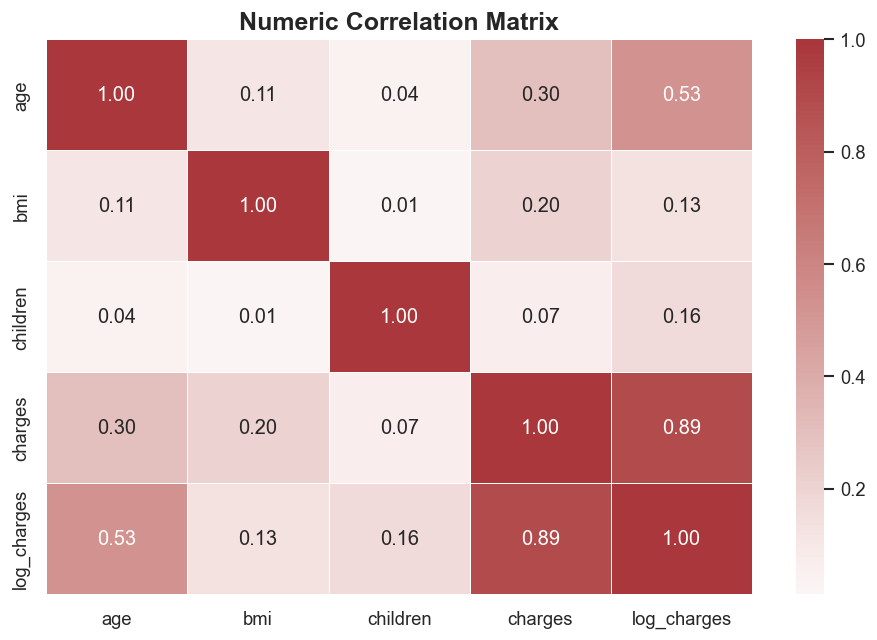

log_charges    0.893
age            0.298
bmi            0.198
children       0.067
Name: charges, dtype: float64

In [12]:
corr_cols = ["age", "bmi", "children", "charges", "log_charges"]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.5)
plt.title("Numeric Correlation Matrix", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task4_correlation_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

corr["charges"].drop("charges").sort_values(ascending=False).round(3)

In [13]:
def calculate_vif(frame, columns):
    numeric = frame[columns].replace([np.inf, -np.inf], np.nan).dropna()
    numeric = numeric.loc[:, numeric.nunique() > 1]
    return (
        pd.DataFrame(
            {
                "feature": numeric.columns,
                "vif": [
                    variance_inflation_factor(numeric.values, i)
                    for i in range(numeric.shape[1])
                ],
            }
        )
        .sort_values("vif", ascending=False)
        .reset_index(drop=True)
    )

calculate_vif(df, ["age", "bmi", "children"]).round(2)

,feature,vif
0,bmi,7.86
1,age,7.54
2,children,1.80


**Research note:** The base numeric predictors do not show a severe multicollinearity problem. That makes multiple regression easier to interpret than in datasets where the inputs are almost duplicates of each other.

## VADER Sentiment Applicability Check

In [14]:
text_columns = [
    col for col in df.columns
    if pd.api.types.is_object_dtype(df[col]) and col not in ["sex", "smoker", "region"]
]

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    vader_available = True
except ImportError:
    vader_available = False

vader_audit = pd.DataFrame(
    {
        "check": ["free_text_columns_available", "vader_package_available", "sentiment_model_used"],
        "result": [bool(text_columns), vader_available, bool(text_columns and vader_available)],
        "note": [
            f"Potential text columns: {text_columns}" if text_columns else "No patient notes, reviews, or comments exist in this dataset.",
            "VADER is available for genuine text fields." if vader_available else "Install vaderSentiment before applying sentiment scoring.",
            "Not applied here because the dataset contains coded categories and numeric health/cost variables.",
        ],
    }
)

vader_audit

,check,result,note
0,free_text_columns_available,False,"No patient notes, reviews, or comments exist i..."
1,vader_package_available,False,Install vaderSentiment before applying sentime...
2,sentiment_model_used,False,Not applied here because the dataset contains ...


## Multiple Regression and Regularization

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

_, _, y_log_train, y_log_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, model_numeric),
        ("cat", categorical_transformer, model_categorical),
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", LinearRegression()),
    ]
)

ridge_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 500])),
    ]
)

lasso_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100], cv=5, max_iter=20000, random_state=RANDOM_STATE)),
    ]
)

log_target_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 500])),
    ]
)

model_results = []
predictions = {}

for name, candidate, train_target, test_target, inverse in [
    ("Multiple Linear Regression", linear_model, y_train, y_test, False),
    ("Ridge Regression", ridge_model, y_train, y_test, False),
    ("Lasso Regression", lasso_model, y_train, y_test, False),
    ("Log-Target Ridge Regression", log_target_model, y_log_train, y_log_test, True),
]:
    candidate.fit(X_train, train_target)
    pred = candidate.predict(X_test)
    if inverse:
        pred_for_metrics = np.expm1(pred)
    else:
        pred_for_metrics = pred

    pred_for_metrics = np.clip(pred_for_metrics, a_min=0, a_max=None)
    predictions[name] = pred_for_metrics
    model_results.append(
        {
            "model": name,
            "mae": mean_absolute_error(y_test, pred_for_metrics),
            "rmse": root_mean_squared_error(y_test, pred_for_metrics),
            "r2": r2_score(y_test, pred_for_metrics),
        }
    )

results_df = pd.DataFrame(model_results).sort_values("rmse")
results_df.round(3)

,model,mae,rmse,r2
0,Multiple Linear Regression,4172.911,5954.758,0.807
1,Ridge Regression,4174.619,5956.302,0.807
2,Lasso Regression,4180.329,5968.056,0.806
3,Log-Target Ridge Regression,3755.712,7193.561,0.718


In [16]:
best_model_name = results_df.iloc[0]["model"]
best_predictions = predictions[best_model_name]

print(f"Best holdout model by RMSE: {best_model_name}")
display(results_df.round(3))

Best holdout model by RMSE: Multiple Linear Regression


,model,mae,rmse,r2
0,Multiple Linear Regression,4172.911,5954.758,0.807
1,Ridge Regression,4174.619,5956.302,0.807
2,Lasso Regression,4180.329,5968.056,0.806
3,Log-Target Ridge Regression,3755.712,7193.561,0.718


## Regression Diagnostics and Error Review

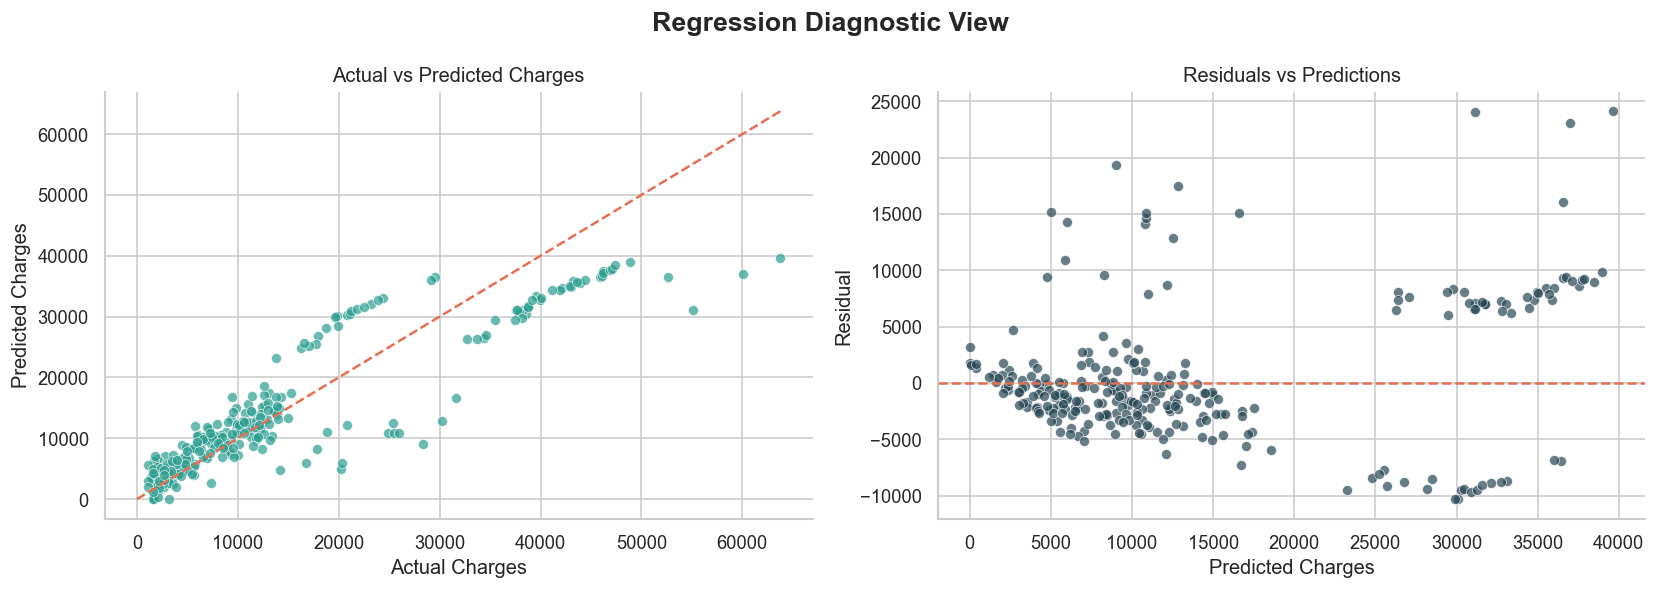

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=best_predictions, alpha=0.7, ax=axes[0], color="#2A9D8F")
limit = max(y_test.max(), best_predictions.max())
axes[0].plot([0, limit], [0, limit], linestyle="--", color="#E76F51")
axes[0].set_title("Actual vs Predicted Charges")
axes[0].set_xlabel("Actual Charges")
axes[0].set_ylabel("Predicted Charges")

residuals = y_test - best_predictions
sns.scatterplot(x=best_predictions, y=residuals, alpha=0.7, ax=axes[1], color="#264653")
axes[1].axhline(0, linestyle="--", color="#E76F51")
axes[1].set_title("Residuals vs Predictions")
axes[1].set_xlabel("Predicted Charges")
axes[1].set_ylabel("Residual")

fig.suptitle("Regression Diagnostic View", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task4_regression_diagnostics.png", dpi=180, bbox_inches="tight")
plt.show()

In [18]:
diagnostic_df = X_test.copy()
diagnostic_df["actual_charges"] = y_test
diagnostic_df["predicted_charges"] = best_predictions
diagnostic_df["absolute_error"] = (diagnostic_df["actual_charges"] - diagnostic_df["predicted_charges"]).abs()

error_by_smoker = (
    diagnostic_df.groupby("smoker")["absolute_error"]
    .agg(test_cases="count", mae="mean", median_abs_error="median")
    .round(2)
)

error_by_region = (
    diagnostic_df.groupby("region")["absolute_error"]
    .agg(test_cases="count", mae="mean", median_abs_error="median")
    .sort_values("mae", ascending=False)
    .round(2)
)

display(error_by_smoker)
display(error_by_region)

,test_cases,mae,median_abs_error
smoker,,,
no,208,2764.94,1862.43
yes,60,9053.87,8361.01


,test_cases,mae,median_abs_error
region,,,
northeast,71,4566.16,2881.50
southeast,77,4456.93,2946.36
northwest,60,3911.51,1884.96
southwest,60,3604.48,2599.61


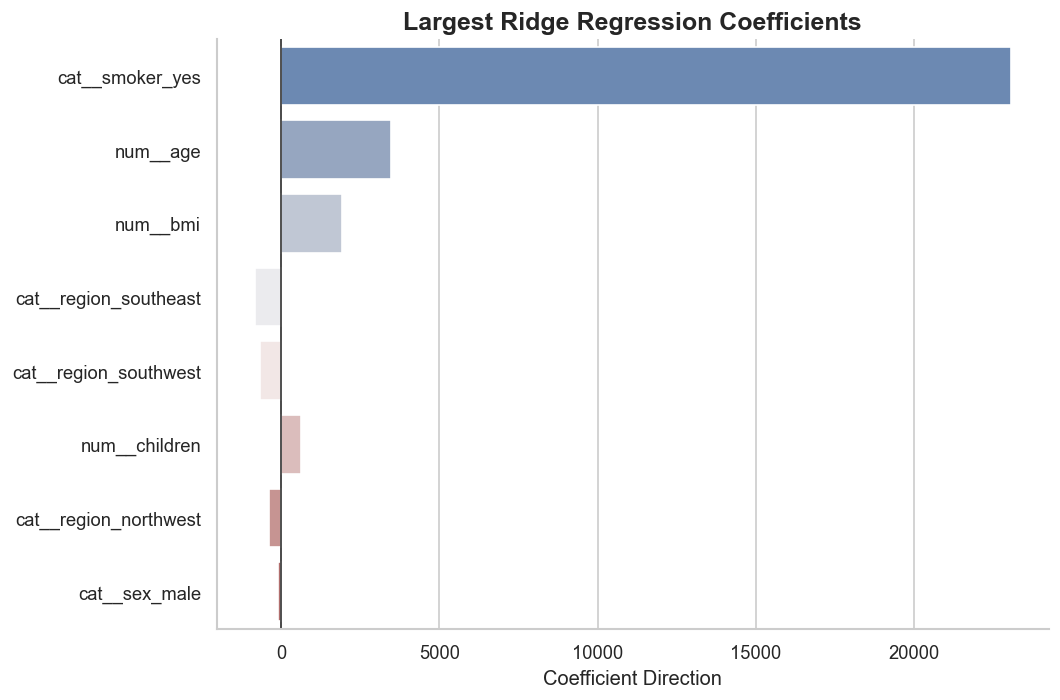

,feature,coefficient
4,cat__smoker_yes,23063.99
0,num__age,3472.52
1,num__bmi,1927.36
6,cat__region_southeast,-836.99
7,cat__region_southwest,-658.48
2,num__children,636.59
5,cat__region_northwest,-391.49
3,cat__sex_male,-100.56


In [19]:
feature_names = ridge_model.named_steps["preprocess"].get_feature_names_out()
ridge_coefs = ridge_model.named_steps["regressor"].coef_

coef_df = (
    pd.DataFrame({"feature": feature_names, "coefficient": ridge_coefs})
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .head(12)
)

plt.figure(figsize=(9, 6))
sns.barplot(data=coef_df, x="coefficient", y="feature", palette="vlag")
plt.axvline(0, color="#333333", linewidth=1)
plt.title("Largest Ridge Regression Coefficients", fontsize=15, fontweight="bold")
plt.xlabel("Coefficient Direction")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task4_ridge_coefficients.png", dpi=180, bbox_inches="tight")
plt.show()

coef_df.drop(columns="abs_coefficient").round(2)

In [20]:
cv_scores = cross_validate(
    ridge_model,
    X,
    y,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    },
)

pd.DataFrame(
    {
        "mae": [-cv_scores["test_mae"].mean(), cv_scores["test_mae"].std()],
        "rmse": [-cv_scores["test_rmse"].mean(), cv_scores["test_rmse"].std()],
        "r2": [cv_scores["test_r2"].mean(), cv_scores["test_r2"].std()],
    },
    index=["mean", "std"],
).round(3)

,mae,rmse,r2
mean,4210.854,6105.163,0.739
std,136.384,200.504,0.044


**Research note:** Regression is useful here because charges are continuous. Still, the residual view matters: medical charges are not perfectly linear, and high-cost cases are harder to estimate. A good final model should be checked by subgroup, especially smoker status, because a low average error can hide uneven performance.

## Final Findings

1. Insurance charges are strongly right-skewed, so medians, log charges, and residual diagnostics are important.
2. Smoking status is the clearest practical cost driver in the dataset. Age and BMI also matter, especially when visualized by smoking status.
3. The base numeric features do not show severe multicollinearity, so multiple regression is reasonable.
4. Linear, Ridge, Lasso, and log-target Ridge regression are compared because this is a true continuous-outcome prediction task.
5. VADER sentiment analysis is not applied because the dataset has no patient notes, reviews, or other free-text fields.
6. The final model should be interpreted as a transparent baseline, not a production pricing tool. Real insurance modeling would need richer claims history, regulatory review, fairness testing, and out-of-time validation.